In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
from diffusers import AutoencoderKL
import matplotlib.pyplot as plt

# Define the transformations and data loaders (same as your original code)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 256  # Smaller batch size due to VAE memory requirements
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-03-21 13:31:02.665937: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742581862.744057    6062 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742581862.767905    6062 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-21 13:31:02.937413: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performanc

In [2]:
import torch.nn.functional as F

In [3]:
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")


Logistic Regression 

In [4]:

class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(28 * 28, 10)  
    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten image
        return self.linear(x)  # No activation (CrossEntropyLoss applies softmax)

In [5]:


# Initialize and train the logistic regression model
logistic_model = LogisticRegressionModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(logistic_model.parameters(), lr=0.001)
# Training
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0
    for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = logistic_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader):.4f}')

# Test phase
logistic_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = logistic_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Base Logistic Regression Accuracy: {correct / total}')

Epoch 1/10: 100%|██████████| 235/235 [00:09<00:00, 23.73it/s]


Epoch [1/10], Loss: 0.6463


Epoch 2/10: 100%|██████████| 235/235 [00:09<00:00, 24.74it/s]


Epoch [2/10], Loss: 0.3682


Epoch 3/10: 100%|██████████| 235/235 [00:09<00:00, 24.19it/s]


...

Epoch [8/10], Loss: 0.2889


Epoch 9/10: 100%|██████████| 235/235 [00:09<00:00, 25.93it/s]


Epoch [9/10], Loss: 0.2865


Epoch 10/10: 100%|██████████| 235/235 [00:09<00:00, 25.32it/s]


Epoch [10/10], Loss: 0.2840
Base Logistic Regression Accuracy: 0.9181


In [6]:
torch.save(logistic_model.state_dict(), 'logregression.pth')

In [7]:

logistic_model.eval()  # Set to evaluation mode
# Freeze the weights
for param in logistic_model.parameters():
    param.requires_grad = False

VAE for mnist


In [8]:

class SimpleVAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(SimpleVAE, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 14x14 -> 7x7
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 7x7 -> 7x7
            nn.LeakyReLU(0.2)
        )
        
        # Mean and variance for the latent space
        self.mu = nn.Linear(128 * 7 * 7, latent_dim)
        self.log_var = nn.Linear(128 * 7 * 7, latent_dim)
        
        # Decoder input layer
        self.decoder_input = nn.Linear(latent_dim, 128 * 7 * 7)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1),  # 7x7 -> 7x7
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7x7 -> 14x14
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Tanh()  # Output normalized between -1 and 1
        )
    
    def encode(self, x):
        # Encode the input
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        
        # Get mean and log variance
        mu = self.mu(h)
        log_var = self.log_var(h)
        
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        # Reparameterization trick
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z):
        # Decode the latent vector
        h = self.decoder_input(z)
        h = h.view(h.size(0), 128, 7, 7)
        return self.decoder(h)
    
    def forward(self, x):
        # Full forward pass
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstructed = self.decode(z)
        return reconstructed, mu, log_var, z

In [9]:

# First, train the VAE
latent_dim = 32  # Size of the latent space
vae = SimpleVAE(latent_dim=latent_dim).to(device)

# VAE training parameters
vae_optimizer = optim.Adam(vae.parameters(), lr=0.001)
vae_epochs = 20  # Just a few epochs to get a decent VAE

def vae_loss_function(recon_x, x, mu, log_var):
    # Reconstruction loss (mean squared error)
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    return MSE + KLD

# Train the VAE
print("Training the VAE...")
for epoch in range(vae_epochs):
    vae.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(tqdm(trainloader, desc=f"VAE Epoch {epoch+1}/{vae_epochs}")):
        data = data.to(device)
        vae_optimizer.zero_grad()
        
        recon_batch, mu, log_var, _ = vae(data)
        loss = vae_loss_function(recon_batch, data, mu, log_var)
        
        loss.backward()
        vae_optimizer.step()
        
        train_loss += loss.item()
        
    print(f'VAE Epoch: {epoch+1}, Loss: {train_loss / len(trainloader.dataset):.6f}')


Training the VAE...


VAE Epoch 1/20: 100%|██████████| 235/235 [00:55<00:00,  4.26it/s]


VAE Epoch: 1, Loss: 144.873637


VAE Epoch 2/20: 100%|██████████| 235/235 [00:59<00:00,  3.95it/s]


VAE Epoch: 2, Loss: 75.790371


...

VAE Epoch: 18, Loss: 60.010858


VAE Epoch 19/20: 100%|██████████| 235/235 [00:55<00:00,  4.21it/s]


VAE Epoch: 19, Loss: 59.761788


VAE Epoch 20/20: 100%|██████████| 235/235 [00:56<00:00,  4.17it/s]

VAE Epoch: 20, Loss: 59.583023


save the vae

In [10]:
torch.save(vae.state_dict(), 'mnist_vae.pth')

In [11]:
# After training, freeze the VAE
vae.eval()
for param in vae.parameters():
    param.requires_grad = False

Visualizing VAE reconstructions...


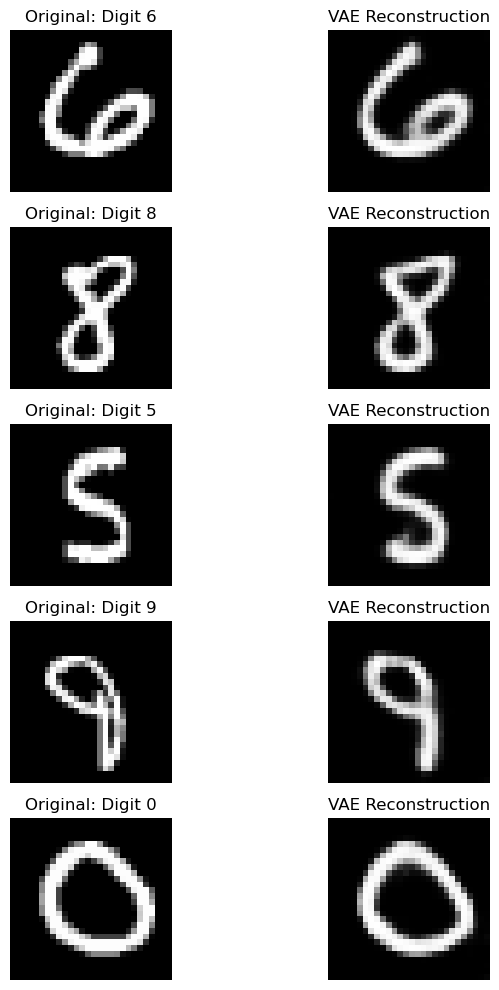

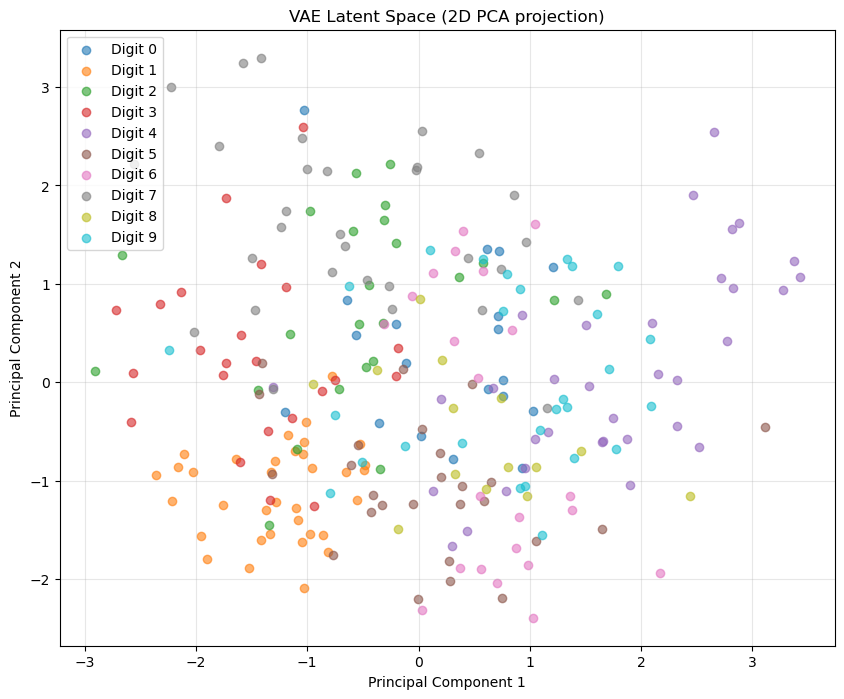

Visualizing latent space interpolation...


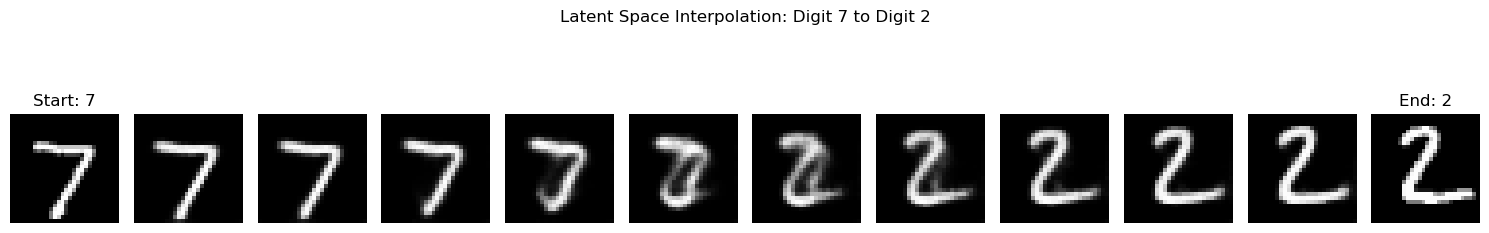

Visualizing random generations from VAE...


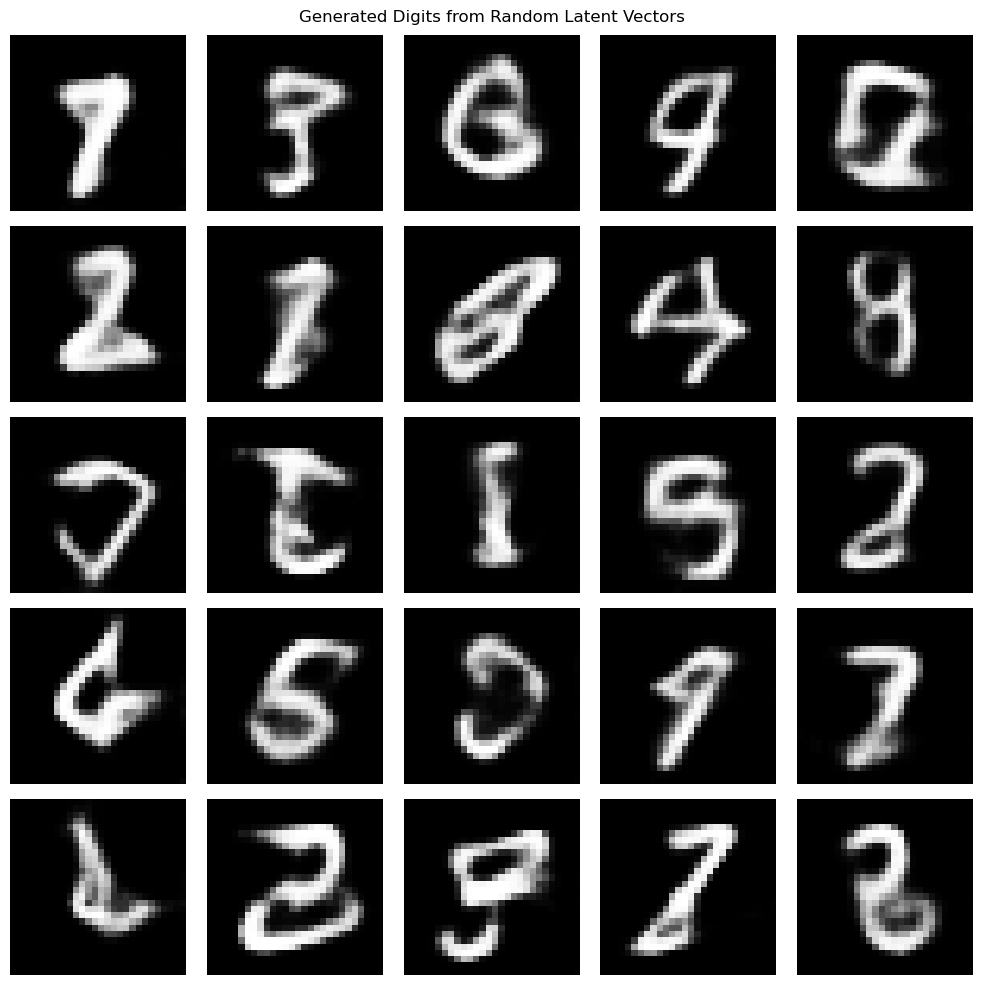


# Add this code right after training the VAE and before freezing it
# i.e., after 'print(f\'VAE Epoch: {epoch+1}, Loss: {train_loss / len(trainloader.dataset):.6f}\')'
# and before 'vae.eval()'

# Visualize VAE results after training
visualize_vae_reconstructions()
visualize_latent_space_interpolation()
visualize_vae_generation()



In [12]:
def visualize_vae_reconstructions():
    """
    Visualize VAE reconstructions for 5 random examples from the test set
    Shows original images and their VAE reconstructions side by side
    """
    # Set VAE to evaluation mode
    vae.eval()
    
    # Get a batch of images from the test set
    dataiter = iter(testloader)
    images, labels = next(dataiter)
    images = images.to(device)
    
    # Select 5 random images from the batch
    random_indices = torch.randperm(len(images))[:5]
    selected_images = images[random_indices]
    selected_labels = labels[random_indices]
    
    # Get VAE reconstructions
    with torch.no_grad():
        reconstructed, mu, log_var, z = vae(selected_images)
    
    # Move tensors to CPU for visualization
    selected_images = selected_images.cpu()
    reconstructed = reconstructed.cpu()
    
    # Plot original and reconstructed images side by side
    fig, axes = plt.subplots(5, 2, figsize=(8, 10))
    
    for i in range(5):
        # Original image
        axes[i, 0].imshow(selected_images[i].squeeze().numpy(), cmap='gray')
        axes[i, 0].set_title(f"Original: Digit {selected_labels[i].item()}")
        axes[i, 0].axis('off')
        
        # Reconstructed image
        axes[i, 1].imshow(reconstructed[i].squeeze().numpy(), cmap='gray')
        axes[i, 1].set_title("VAE Reconstruction")
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('vae_reconstructions.png')
    plt.show()
    
    # Also visualize the latent space representations
    visualize_latent_space(images[:500], labels[:500])

def visualize_latent_space(images, labels):
    """
    Create a 2D visualization of the latent space using PCA
    Color points by digit class
    """
    from sklearn.decomposition import PCA
    
    vae.eval()
    
    # Encode images to get latent representations
    with torch.no_grad():
        mu, _ = vae.encode(images)
        latent_vectors = mu.cpu().numpy()
    
    # Apply PCA to reduce to 2 dimensions for visualization
    pca = PCA(n_components=2)
    latent_2d = pca.fit_transform(latent_vectors)
    
    # Plot the 2D latent space
    plt.figure(figsize=(10, 8))
    
    # Color by digit class
    for digit in range(10):
        idx = labels.numpy() == digit
        plt.scatter(latent_2d[idx, 0], latent_2d[idx, 1], label=f'Digit {digit}', alpha=0.6)
    
    plt.title('VAE Latent Space (2D PCA projection)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig('vae_latent_space.png')
    plt.show()

def visualize_latent_space_interpolation():
    """
    Generate interpolations between two digits in latent space
    """
    vae.eval()
    
    # Get some test images
    dataiter = iter(testloader)
    images, labels = next(dataiter)
    images = images.to(device)
    
    # Find indices of two different digits (e.g., 0 and 1)
    # We'll look for specific digits to make the interpolation more interesting
    digit_indices = {}
    for i, label in enumerate(labels):
        digit = label.item()
        if digit not in digit_indices:
            digit_indices[digit] = i
        
        # If we found at least two different digits, we can stop
        if len(digit_indices) >= 2:
            break
    
    # Select two different digits
    digits = list(digit_indices.keys())[:2]
    idx1, idx2 = digit_indices[digits[0]], digit_indices[digits[1]]
    
    # Get latent representations
    with torch.no_grad():
        mu1, _ = vae.encode(images[idx1].unsqueeze(0))
        mu2, _ = vae.encode(images[idx2].unsqueeze(0))
    
    # Create interpolations
    num_steps = 10
    interpolations = torch.zeros(num_steps, 1, 28, 28).to(device)
    
    for i in range(num_steps):
        # Linear interpolation between mu1 and mu2
        alpha = i / (num_steps - 1)
        mu_interp = (1 - alpha) * mu1 + alpha * mu2
        
        # Decode the interpolated latent vector
        interpolated_image = vae.decode(mu_interp)
        interpolations[i] = interpolated_image
    
    # Plot the interpolation
    plt.figure(figsize=(15, 3))
    
    # Plot original start image
    plt.subplot(1, num_steps + 2, 1)
    plt.imshow(images[idx1].cpu().squeeze().numpy(), cmap='gray')
    plt.title(f'Start: {digits[0]}')
    plt.axis('off')
    
    # Plot interpolations
    for i in range(num_steps):
        plt.subplot(1, num_steps + 2, i + 2)
        plt.imshow(interpolations[i].cpu().squeeze().numpy(), cmap='gray')
        plt.axis('off')
    
    # Plot original end image
    plt.subplot(1, num_steps + 2, num_steps + 2)
    plt.imshow(images[idx2].cpu().squeeze().numpy(), cmap='gray')
    plt.title(f'End: {digits[1]}')
    plt.axis('off')
    
    plt.suptitle(f'Latent Space Interpolation: Digit {digits[0]} to Digit {digits[1]}')
    plt.tight_layout()
    plt.savefig('vae_interpolation.png')
    plt.show()

def visualize_vae_generation():
    """
    Generate new digit images by sampling from the latent space
    """
    vae.eval()
    
    # Create a grid of random latent vectors
    grid_size = 5
    num_samples = grid_size * grid_size
    
    # Sample random points from the latent space (standard normal distribution)
    with torch.no_grad():
        # Create random latent vectors
        random_latent = torch.randn(num_samples, latent_dim).to(device)
        
        # Decode the random latent vectors
        generated_images = vae.decode(random_latent)
    
    # Plot the generated images
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    
    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            axes[i, j].imshow(generated_images[idx].cpu().squeeze().numpy(), cmap='gray')
            axes[i, j].axis('off')
    
    plt.suptitle('Generated Digits from Random Latent Vectors')
    plt.tight_layout()
    plt.savefig('vae_generated_digits.png')
    plt.show()

# Run all the visualizations
print("Visualizing VAE reconstructions...")
visualize_vae_reconstructions()

print("Visualizing latent space interpolation...")
visualize_latent_space_interpolation()

print("Visualizing random generations from VAE...")
visualize_vae_generation()

# Function to insert this code in the right place in your pipeline
def insert_vae_visualization_code():
    print("\n# Add this code right after training the VAE and before freezing it")
    print("# i.e., after 'print(f\\'VAE Epoch: {epoch+1}, Loss: {train_loss / len(trainloader.dataset):.6f}\\')'")
    print("# and before 'vae.eval()'")
    
    print("""
# Visualize VAE results after training
visualize_vae_reconstructions()
visualize_latent_space_interpolation()
visualize_vae_generation()
""")

insert_vae_visualization_code()

In [7]:


# 3. Define the latent transformer network
class LatentTransformer(nn.Module):
    def __init__(self, latent_dim=32):
        super(LatentTransformer, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, latent_dim)
        )
    
    def forward(self, x):
        return self.net(x)

# 4. Define the full pipeline
class VAEClassifierPipeline(nn.Module):
    def __init__(self, vae, transformer, classifier, alpha=0.5):
        super(VAEClassifierPipeline, self).__init__()
        self.vae = vae
        self.transformer = transformer
        self.classifier = classifier
        self.alpha = alpha  # Weight for the MSE loss component
    
    def forward(self, x):
        # 1. Encode with VAE to get latent representation
        with torch.no_grad():
            mu, log_var = self.vae.encode(x)
            z = self.vae.reparameterize(mu, log_var)
        
        original_latent = z.detach()  # Keep original for MSE loss
        
        # 2. Transform the latent representation
        transformed_latent = self.transformer(z)
        
        # 3. Decode the transformed latent
        with torch.no_grad():
            decoded = self.vae.decode(transformed_latent)
        
        # 4. Pass through the classifier
        logits = self.classifier(decoded)
        
        return {
            'logits': logits,
            'decoded_image': decoded,
            'original_latent': original_latent,
            'transformed_latent': transformed_latent
        }


# After training, freeze the VAE
vae.eval()
for param in vae.parameters():
    param.requires_grad = False

# Now set up the latent transformer and pipeline
latent_transformer = LatentTransformer(latent_dim=latent_dim).to(device)
pipeline = VAEClassifierPipeline(vae, latent_transformer, logistic_model).to(device)

# Only train the transformer part
optimizer = optim.Adam(latent_transformer.parameters(), lr=0.0005)
classification_criterion = nn.CrossEntropyLoss()
mse_criterion = nn.MSELoss()

# Training loop for the latent transformer
print("Training the latent space transformer...")
num_epochs = 15
for epoch in range(num_epochs):
    pipeline.train()  # Only the transformer is trainable
    running_loss = 0.0
    running_class_loss = 0.0
    running_mse_loss = 0.0
    
    for images, labels in tqdm(trainloader, desc=f"Transformer Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = pipeline(images)
        
        # Calculate the classification loss
        class_loss = classification_criterion(outputs['logits'], labels)
        
        # Calculate the MSE loss between original and transformed latent
        mse_loss = mse_criterion(outputs['transformed_latent'], outputs['original_latent'])
        
        # Combined loss
        alpha = pipeline.alpha
        total_loss = class_loss + mse_loss
        
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        running_class_loss += class_loss.item()
        running_mse_loss += mse_loss.item()
    
    avg_loss = running_loss / len(trainloader)
    avg_class_loss = running_class_loss / len(trainloader)
    avg_mse_loss = running_mse_loss / len(trainloader)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Total Loss: {avg_loss:.4f}, '
          f'Class Loss: {avg_class_loss:.4f}, '
          f'MSE Loss: {avg_mse_loss:.4f}')

# Evaluation
pipeline.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(testloader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = pipeline(images)
        _, predicted = torch.max(outputs['logits'].data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy with Latent Transformation: {100 * correct / total:.2f}%')

# Optional: Evaluate original logistic regression on unmodified images
logistic_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(testloader, desc="Evaluating Original Logistic Model"):
        images, labels = images.to(device), labels.to(device)
        outputs = logistic_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Original Logistic Regression Accuracy: {100 * correct / total:.2f}%')

# Optional: Save the trained models
torch.save(vae.state_dict(), 'mnist_vae.pth')
torch.save(latent_transformer.state_dict(), 'latent_transformer.pth')

Training the VAE...


VAE Epoch 1/10: 100%|██████████| 235/235 [00:54<00:00,  4.32it/s]


VAE Epoch: 1, Loss: 121.559794


VAE Epoch 2/10: 100%|██████████| 235/235 [00:54<00:00,  4.30it/s]


VAE Epoch: 2, Loss: 72.478945


...

Epoch [15/15], Total Loss: 0.3009, Class Loss: 0.3005, MSE Loss: 0.0005


Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.49it/s]


Test Accuracy with Latent Transformation: 91.18%


Evaluating Original Logistic Model: 100%|██████████| 40/40 [00:01<00:00, 20.67it/s]

Original Logistic Regression Accuracy: 92.05%


In [8]:
import matplotlib.pyplot as plt

In [9]:
# Code to find and visualize examples where the transformation improved classification
def find_improved_examples(original_model, combined_model, test_loader, num_examples=10):
    original_model.eval()
    combined_model.eval()
    
    improved_images = []
    true_labels = []
    original_preds = []
    improved_preds = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Get predictions from original model
            original_outputs = original_model(images)
            _, original_predictions = torch.max(original_outputs, 1)
            
            # Get predictions from combined model
            combined_outputs, transformed_images = combined_model(images)
            _, combined_predictions = torch.max(combined_outputs, 1)
            
            # Find examples where original model was wrong but combined model is correct
            improved_mask = (original_predictions != labels) & (combined_predictions == labels)
            
            if improved_mask.any():
                improved_images.append((images[improved_mask], transformed_images[improved_mask]))
                true_labels.append(labels[improved_mask])
                original_preds.append(original_predictions[improved_mask])
                improved_preds.append(combined_predictions[improved_mask])
            
            # Check if we have enough examples
            total_found = sum(len(batch) for batch in true_labels)
            if total_found >= num_examples:
                break
    
    # Combine the first num_examples
    selected_images = []
    selected_transformed = []
    selected_labels = []
    selected_original_preds = []
    selected_improved_preds = []
    
    examples_needed = num_examples
    for i in range(len(true_labels)):
        batch_size = len(true_labels[i])
        take = min(examples_needed, batch_size)
        
        selected_images.append(improved_images[i][0][:take])
        selected_transformed.append(improved_images[i][1][:take])
        selected_labels.append(true_labels[i][:take])
        selected_original_preds.append(original_preds[i][:take])
        selected_improved_preds.append(improved_preds[i][:take])
        
        examples_needed -= take
        if examples_needed <= 0:
            break
    
    # Concatenate all selected examples
    if selected_images:
        selected_images = torch.cat(selected_images)
        selected_transformed = torch.cat(selected_transformed)
        selected_labels = torch.cat(selected_labels)
        selected_original_preds = torch.cat(selected_original_preds)
        selected_improved_preds = torch.cat(selected_improved_preds)
        
        return selected_images, selected_transformed, selected_labels, selected_original_preds, selected_improved_preds
    else:
        return None

# Find examples where transformation improved classification
print("Finding examples where the transformation network improved classification...")
improved_data = find_improved_examples(logistic_model, pipeline, testloader, num_examples=10)

if improved_data:
    images, transformed_images, true_labels, original_preds, improved_preds = improved_data
    
    # Denormalize images for visualization (from [-1,1] to [0,1])
    images_viz = (images * 0.5) + 0.5
    transformed_viz = (transformed_images * 0.5) + 0.5
    
    # Visualize the improved examples
    plt.figure(figsize=(20, 15))
    
    for i in range(min(10, images.size(0))):
        # Original image with incorrect prediction
        plt.subplot(3, 10, i + 1)
        plt.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original Image")
        plt.axis('off')
        
        # Original prediction (incorrect)
        plt.subplot(3, 10, i + 11)
        plt.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original Pred: {original_preds[i].item()}")
        plt.xlabel(f"True Label: {true_labels[i].item()}")
        plt.axis('off')
        
        # Transformed image with correct prediction
        plt.subplot(3, 10, i + 21)
        plt.imshow(transformed_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Transformed")
        plt.xlabel(f"Pred: {improved_preds[i].item()} ✓")
        plt.axis('off')
    
    plt.suptitle("Examples where transformation improved classification", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    # Additional detailed 2x5 grid visualization
    plt.figure(figsize=(15, 6))
    for i in range(min(10, images.size(0))):
        plt.subplot(2, 5, i + 1)
        
        # Create a side-by-side comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
        
        # Original image
        ax1.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        ax1.set_title(f"Original\nPred: {original_preds[i].item()} ✗")
        ax1.axis('off')
        
        # Transformed image
        ax2.imshow(transformed_viz[i].cpu().squeeze().numpy(), cmap='gray')
        ax2.set_title(f"Transformed\nPred: {improved_preds[i].item()} ✓")
        ax2.axis('off')
        
        plt.suptitle(f"True Label: {true_labels[i].item()}")
        plt.tight_layout()
        plt.show()
else:
    print("Could not find enough examples where transformation improved classification.")
    print("This could mean either the original model is already very accurate or the transformation did not help significantly.")
    print("Try running the training for more epochs or adjusting the transformation network architecture.")

Finding examples where the transformation network improved classification...


ValueError: too many values to unpack (expected 2)

Testing a different architecture

In [5]:
logistic_model.eval() 
for param in logistic_model.parameters():
    param.requires_grad = False

# 2. Load the pretrained VAE
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
# Freeze VAE weights
for param in vae.parameters():
    param.requires_grad = False

# 3. Define the deep neural network for latent space transformation
class LatentTransformer(nn.Module):
    def __init__(self, latent_dim=4):
        super(LatentTransformer, self).__init__()
        # Assuming the VAE latent space has dimensions latent_dim × h × w
        # For SD-VAE, the latent space is typically 4×h/8×w/8
        self.latent_dim = latent_dim
        
        # A deeper network for latent space transformation
        self.net = nn.Sequential(
            nn.Conv2d(latent_dim, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, latent_dim, kernel_size=3, padding=1)
        )
    
    def forward(self, x):
        return self.net(x)

# 4. Define the full pipeline
class VAEClassifierPipeline(nn.Module):
    def __init__(self, vae, transformer, classifier, alpha=0.5):
        super(VAEClassifierPipeline, self).__init__()
        self.vae = vae
        self.transformer = transformer
        self.classifier = classifier
        self.alpha = alpha  # Weight for the MSE loss component
    
    def forward(self, x):
        # 1. Resize MNIST to match VAE input expectations (assuming 512x512)
        # SD-VAE expects 3-channel images
        x_resized = torch.nn.functional.interpolate(
            x.repeat(1, 3, 1, 1),  # Convert grayscale to RGB by repeating
            size=(512, 512),
            mode='bilinear',
            align_corners=False
        )
        
        # 2. Encode with VAE to get latent representation
        with torch.no_grad():
            latent = self.vae.encode(x_resized).latent_dist.sample()
        original_latent = latent.detach()  # Keep original for MSE loss
        
        # 3. Transform the latent representation
        transformed_latent = self.transformer(latent)
        
        # 4. Decode the transformed latent
        with torch.no_grad():
            decoded = self.vae.decode(transformed_latent).sample
        
        # 5. Resize back to MNIST size (28x28)
        decoded_resized = torch.nn.functional.interpolate(
            decoded,
            size=(28, 28),
            mode='bilinear',
            align_corners=False
        )
        # Convert RGB to grayscale by taking the mean across channels
        decoded_mnist = decoded_resized.mean(dim=1, keepdim=True)
        
        # 6. Pass through the classifier
        logits = self.classifier(decoded_mnist)
        
        return {
            'logits': logits,
            'decoded_image': decoded_mnist,
            'original_latent': original_latent,
            'transformed_latent': transformed_latent
        }



In [6]:
# Initialize the latent transformer and the full pipeline
latent_transformer = LatentTransformer().to(device)
pipeline = VAEClassifierPipeline(vae, latent_transformer, logistic_model).to(device)

# Only train the transformer part
optimizer = optim.Adam(latent_transformer.parameters(), lr=0.0001)
classification_criterion = nn.CrossEntropyLoss()
mse_criterion = nn.MSELoss()

# Training loop
print("Training the latent space transformer...")
num_epochs = 10
for epoch in range(num_epochs):
    pipeline.train()
    running_loss = 0.0
    running_class_loss = 0.0
    running_mse_loss = 0.0
    
    for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = pipeline(images)
        
        # Calculate the classification loss
        class_loss = classification_criterion(outputs['logits'], labels)
        
        # Calculate the MSE loss between original and transformed latent
        mse_loss = mse_criterion(outputs['transformed_latent'], outputs['original_latent'])
        
        # Combined loss
        alpha = pipeline.alpha
        total_loss = class_loss + alpha * mse_loss
        
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        running_class_loss += class_loss.item()
        running_mse_loss += mse_loss.item()
    
    avg_loss = running_loss / len(trainloader)
    avg_class_loss = running_class_loss / len(trainloader)
    avg_mse_loss = running_mse_loss / len(trainloader)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Total Loss: {avg_loss:.4f}, '
          f'Class Loss: {avg_class_loss:.4f}, '
          f'MSE Loss: {avg_mse_loss:.4f}')

# Evaluation
pipeline.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(testloader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = pipeline(images)
        _, predicted = torch.max(outputs['logits'].data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy with Latent Transformation: {100 * correct / total:.2f}%')

# Optional: Save the trained transformer
torch.save(latent_transformer.state_dict(), 'latent_transformer.pth')

Training the latent space transformer...


Epoch 1/10:   0%|          | 0/938 [00:00<?, ?it/s]

: 

: 

Tutor AI + Combined model

In [7]:
# Define the image transformation network
class ImageTransformNetwork(nn.Module):
    def __init__(self, hidden_dims=64):
        super(ImageTransformNetwork, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, hidden_dims, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dims, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()  # Output in range [-1,1] to match normalization
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Combine transformer and classifier
class CombinedModel(nn.Module):
    def __init__(self, transformer, classifier):
        super(CombinedModel, self).__init__()
        self.transformer = transformer
        self.classifier = classifier
        
        # Freeze the classifier parameters
        for param in self.classifier.parameters():
            param.requires_grad = False
            
    def forward(self, x):
        transformed = self.transformer(x)
        return self.classifier(transformed), transformed

Training the combined model

In [8]:
# Create an object from combined model
transform_net = ImageTransformNetwork().to(device)
combined_model = CombinedModel(transform_net, logistic_model).to(device)

# Loss for logregression: crossentropy
# I am gonna try reduction='sum' 
# This is because we wanna make sure there is not much
# Wiggle room for the images to get messed up
# penalizing all problems
classification_criterion = nn.CrossEntropyLoss(reduction='sum')
# This is so that the new image is not tooo different from
# The old image
reconstruction_criterion = nn.MSELoss()
transform_optimizer = optim.Adam(transform_net.parameters(), lr=0.001)

# Hyperparameters for the combined loss
classification_weight = 1.0
reconstruction_weight = 0.1 

# Training loop for the transformer network
print("Training the transformer network")
num_epochs = 20
for epoch in range(num_epochs):
    transform_net.train()
    running_loss = 0.0
    running_class_loss = 0.0
    running_recon_loss = 0.0
    
    for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        transform_optimizer.zero_grad()
        
        # Forward pass through the combined model
        outputs, transformed_images = combined_model(images)
        
        # Calculate losses
        classification_loss = classification_criterion(outputs, labels)
        reconstruction_loss = reconstruction_criterion(transformed_images, images)
        
        # Combined loss
        total_loss = classification_weight * classification_loss + reconstruction_weight * reconstruction_loss
        
        # Backward and optimize
        total_loss.backward()
        transform_optimizer.step()
        
        running_loss += total_loss.item()
        running_class_loss += classification_loss.item()
        running_recon_loss += reconstruction_loss.item()
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Total Loss: {running_loss/len(trainloader):.4f}, '
          f'Classification Loss: {running_class_loss/len(trainloader):.4f}, '
          f'Reconstruction Loss: {running_recon_loss/len(trainloader):.4f}')

# Evaluate the combined model
combined_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs, _ = combined_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Enhanced Model Accuracy: {100 * correct / total:.2f}%')



Training the transformer network...


Epoch 1/20: 100%|██████████| 235/235 [01:02<00:00,  3.76it/s]


Epoch [1/20], Total Loss: 1897.4147, Classification Loss: 107.3315, Reconstruction Loss: 8950.4160


Epoch 2/20: 100%|██████████| 235/235 [00:58<00:00,  4.01it/s]


Epoch [2/20], Total Loss: 258.4618, Classification Loss: 70.4126, Reconstruction Loss: 940.2459


...

Epoch [18/20], Total Loss: 92.4673, Classification Loss: 70.0097, Reconstruction Loss: 112.2882


Epoch 19/20: 100%|██████████| 235/235 [01:10<00:00,  3.32it/s]


Epoch [19/20], Total Loss: 93.5546, Classification Loss: 70.0186, Reconstruction Loss: 117.6804


Epoch 20/20: 100%|██████████| 235/235 [01:05<00:00,  3.57it/s]


Epoch [20/20], Total Loss: 89.6676, Classification Loss: 69.9754, Reconstruction Loss: 98.4607
Enhanced Model Accuracy: 92.11%


Visualizing results

Visualizig images that were incorrectly classified in the logistic regression classifier but are now classified correctly in the combined model

Finding examples where the transformation network improved classification...


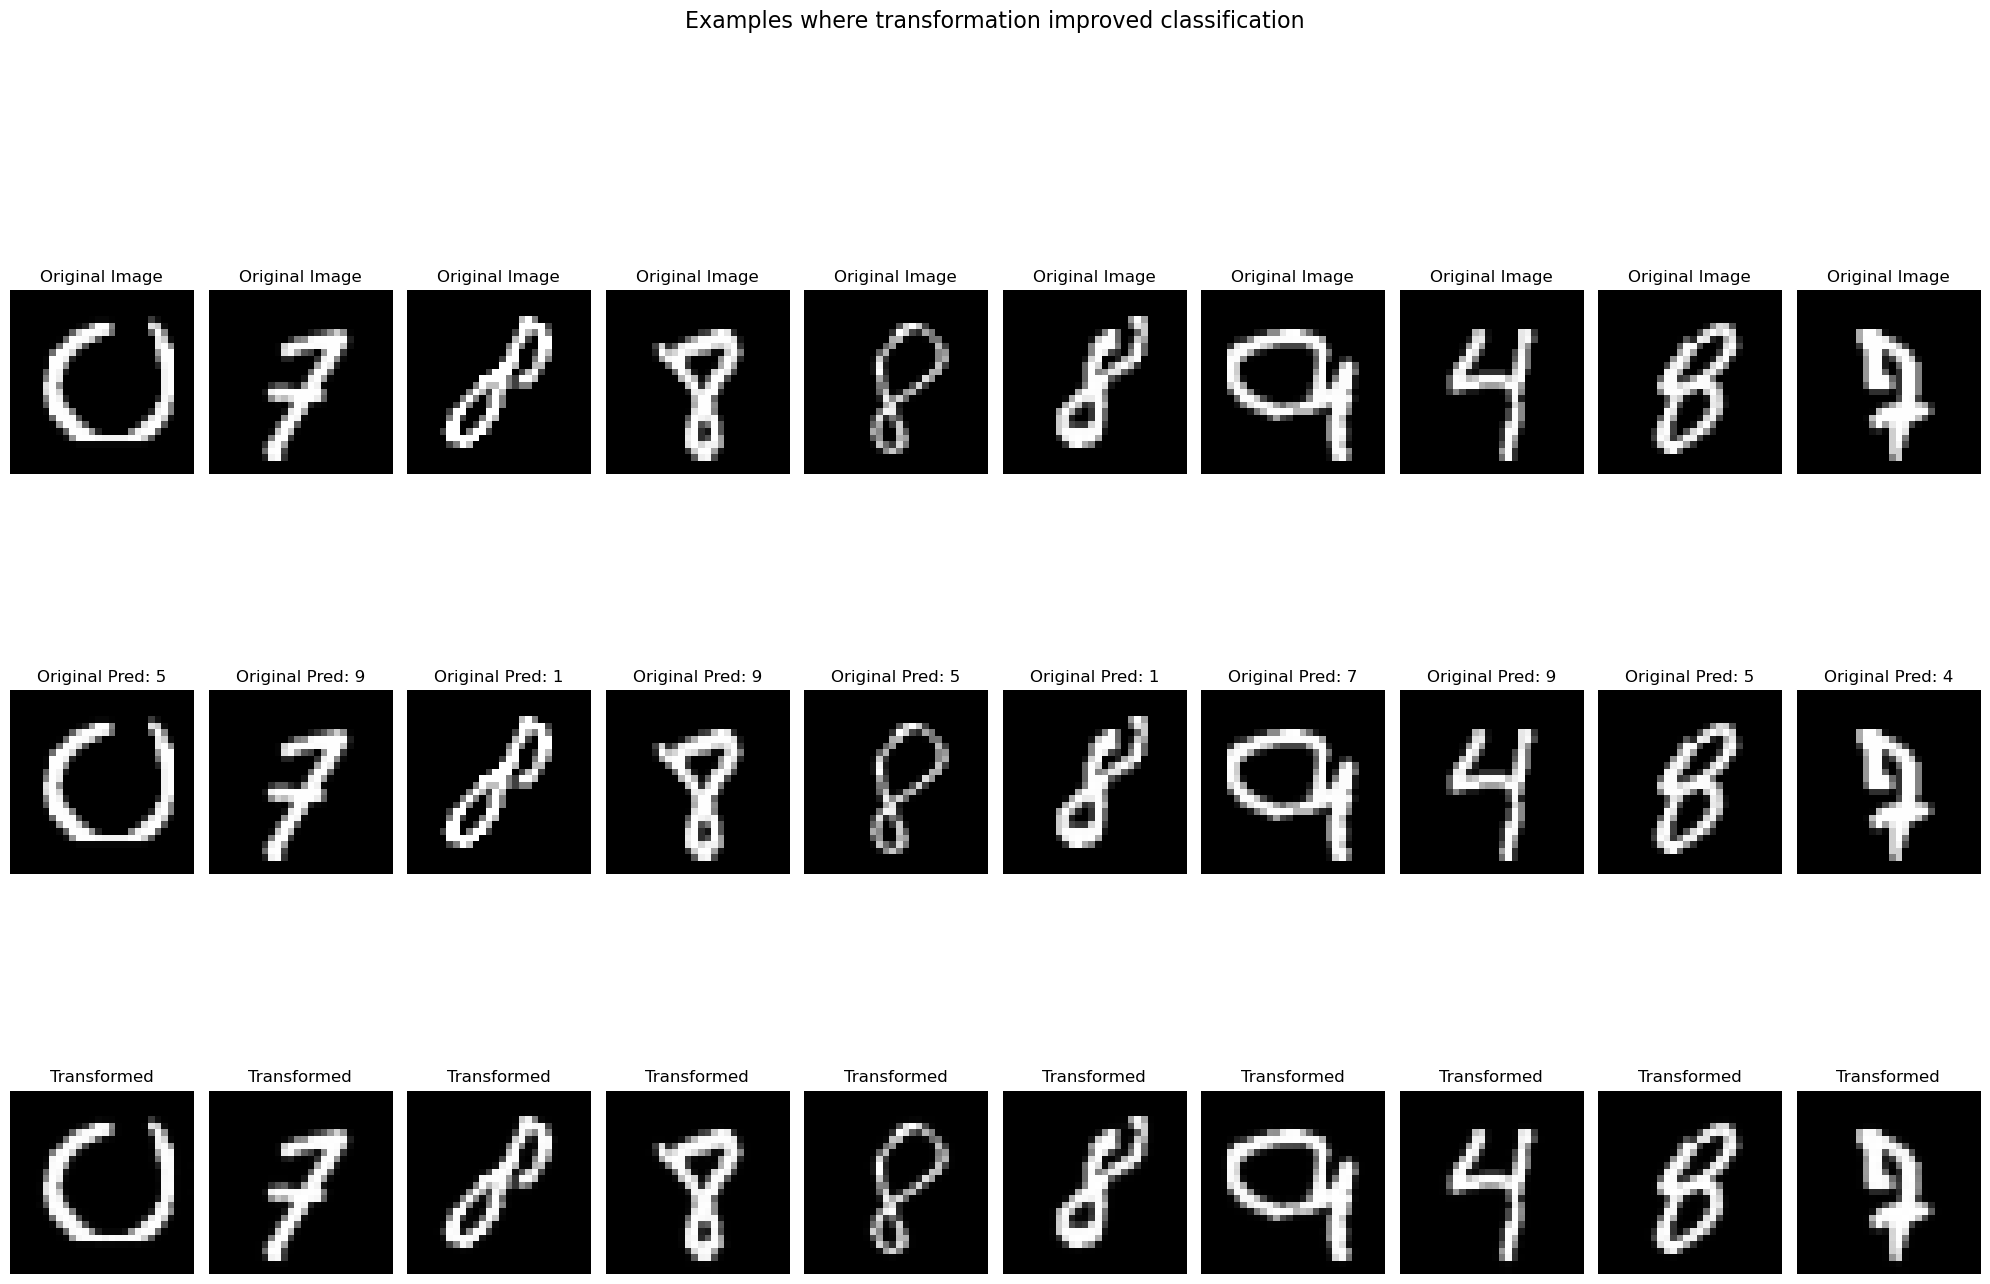

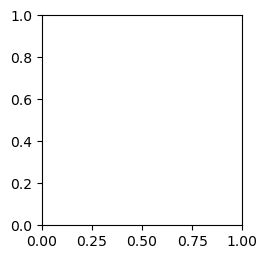

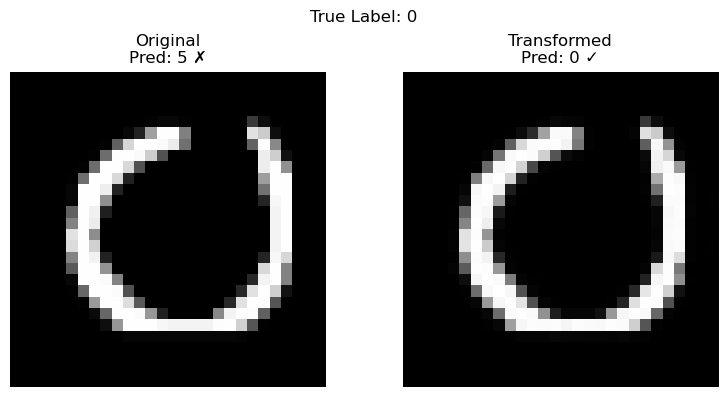

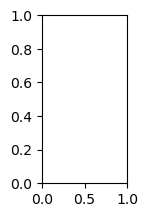

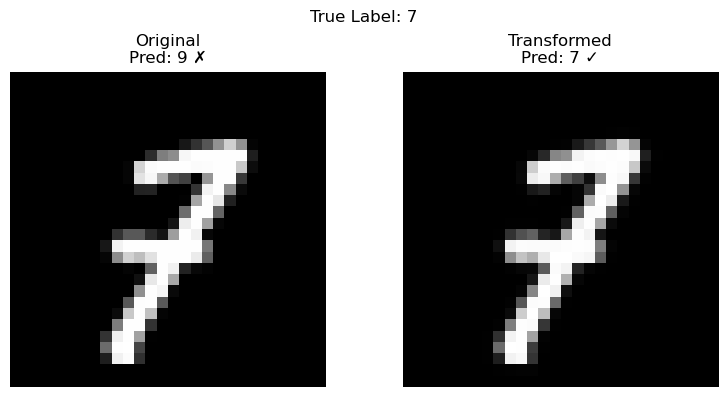

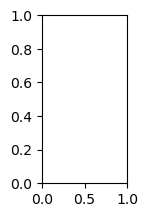

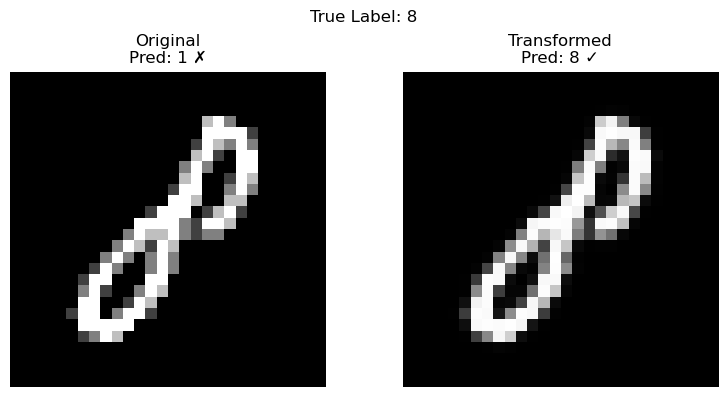

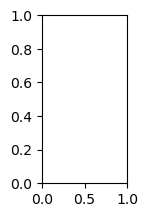

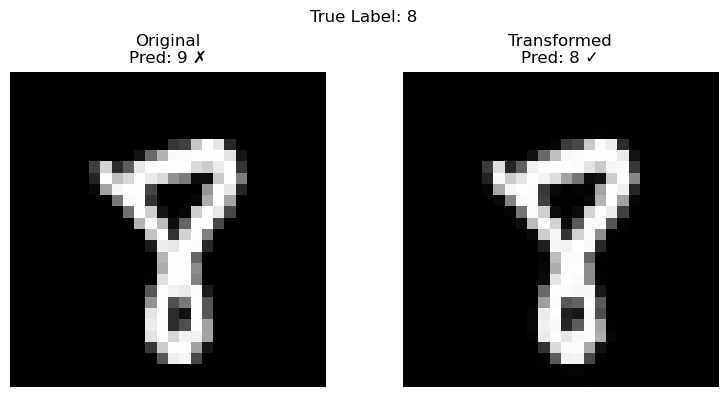

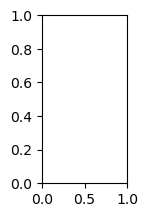

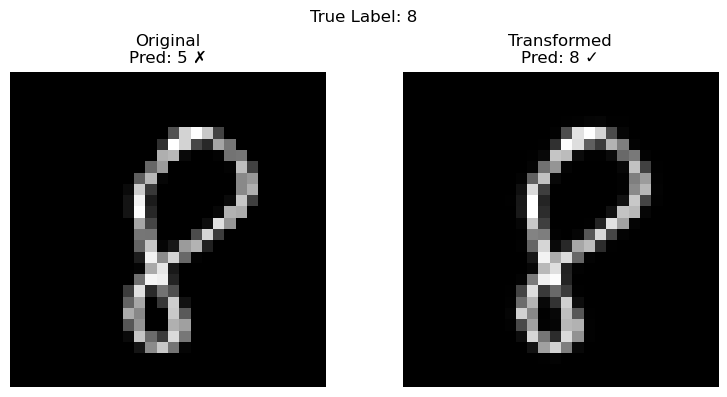

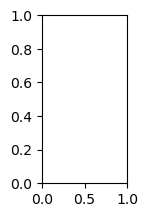

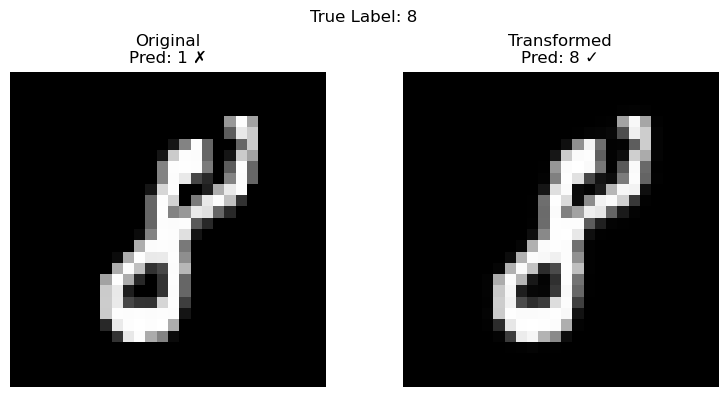

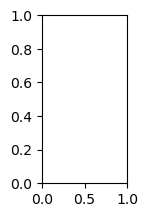

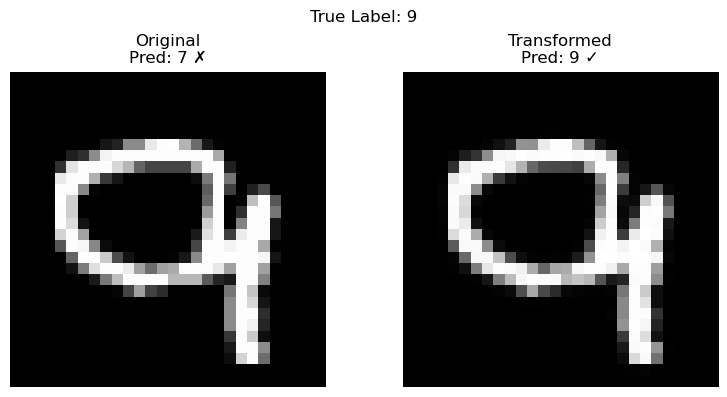

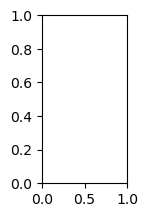

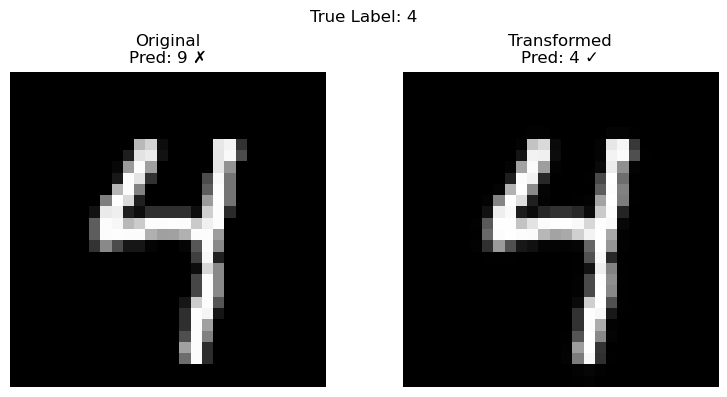

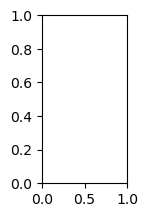

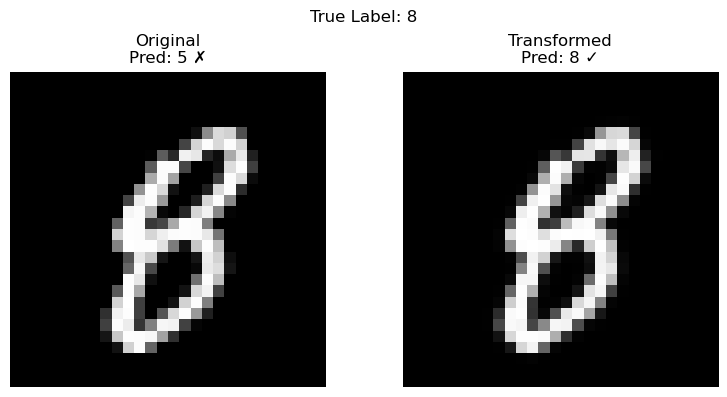

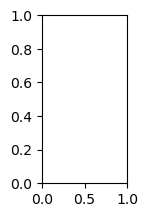

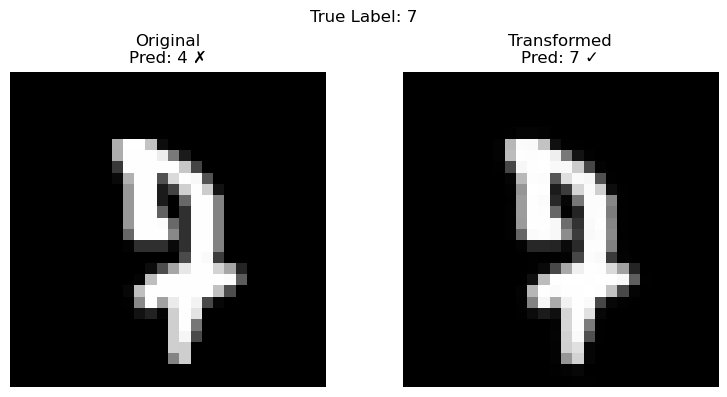

In [10]:
# Code to find and visualize examples where the transformation improved classification
def find_improved_examples(original_model, combined_model, test_loader, num_examples=10):
    original_model.eval()
    combined_model.eval()
    
    improved_images = []
    true_labels = []
    original_preds = []
    improved_preds = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Get predictions from original model
            original_outputs = original_model(images)
            _, original_predictions = torch.max(original_outputs, 1)
            
            # Get predictions from combined model
            combined_outputs, transformed_images = combined_model(images)
            _, combined_predictions = torch.max(combined_outputs, 1)
            
            # Find examples where original model was wrong but combined model is correct
            improved_mask = (original_predictions != labels) & (combined_predictions == labels)
            
            if improved_mask.any():
                improved_images.append((images[improved_mask], transformed_images[improved_mask]))
                true_labels.append(labels[improved_mask])
                original_preds.append(original_predictions[improved_mask])
                improved_preds.append(combined_predictions[improved_mask])
            
            # Check if we have enough examples
            total_found = sum(len(batch) for batch in true_labels)
            if total_found >= num_examples:
                break
    
    # Combine the first num_examples
    selected_images = []
    selected_transformed = []
    selected_labels = []
    selected_original_preds = []
    selected_improved_preds = []
    
    examples_needed = num_examples
    for i in range(len(true_labels)):
        batch_size = len(true_labels[i])
        take = min(examples_needed, batch_size)
        
        selected_images.append(improved_images[i][0][:take])
        selected_transformed.append(improved_images[i][1][:take])
        selected_labels.append(true_labels[i][:take])
        selected_original_preds.append(original_preds[i][:take])
        selected_improved_preds.append(improved_preds[i][:take])
        
        examples_needed -= take
        if examples_needed <= 0:
            break
    
    # Concatenate all selected examples
    if selected_images:
        selected_images = torch.cat(selected_images)
        selected_transformed = torch.cat(selected_transformed)
        selected_labels = torch.cat(selected_labels)
        selected_original_preds = torch.cat(selected_original_preds)
        selected_improved_preds = torch.cat(selected_improved_preds)
        
        return selected_images, selected_transformed, selected_labels, selected_original_preds, selected_improved_preds
    else:
        return None

# Find examples where transformation improved classification
print("Finding examples where the transformation network improved classification...")
improved_data = find_improved_examples(logistic_model, combined_model, testloader, num_examples=10)

if improved_data:
    images, transformed_images, true_labels, original_preds, improved_preds = improved_data
    
    # Denormalize images for visualization (from [-1,1] to [0,1])
    images_viz = (images * 0.5) + 0.5
    transformed_viz = (transformed_images * 0.5) + 0.5
    
    # Visualize the improved examples
    plt.figure(figsize=(20, 15))
    
    for i in range(min(10, images.size(0))):
        # Original image with incorrect prediction
        plt.subplot(3, 10, i + 1)
        plt.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original Image")
        plt.axis('off')
        
        # Original prediction (incorrect)
        plt.subplot(3, 10, i + 11)
        plt.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original Pred: {original_preds[i].item()}")
        plt.xlabel(f"True Label: {true_labels[i].item()}")
        plt.axis('off')
        
        # Transformed image with correct prediction
        plt.subplot(3, 10, i + 21)
        plt.imshow(transformed_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Transformed")
        plt.xlabel(f"Pred: {improved_preds[i].item()} ✓")
        plt.axis('off')
    
    plt.suptitle("Examples where transformation improved classification", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    # Additional detailed 2x5 grid visualization
    plt.figure(figsize=(15, 6))
    for i in range(min(10, images.size(0))):
        plt.subplot(2, 5, i + 1)
        
        # Create a side-by-side comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
        
        # Original image
        ax1.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        ax1.set_title(f"Original\nPred: {original_preds[i].item()} ✗")
        ax1.axis('off')
        
        # Transformed image
        ax2.imshow(transformed_viz[i].cpu().squeeze().numpy(), cmap='gray')
        ax2.set_title(f"Transformed\nPred: {improved_preds[i].item()} ✓")
        ax2.axis('off')
        
        plt.suptitle(f"True Label: {true_labels[i].item()}")
        plt.tight_layout()
        plt.show()
else:
    print("Could not find enough examples where transformation improved classification.")
    print("This could mean either the original model is already very accurate or the transformation did not help significantly.")
    print("Try running the training for more epochs or adjusting the transformation network architecture.")

Kfold Validation

Training the logistic regression model...


Epoch 1/8: 100%|██████████| 235/235 [00:09<00:00, 25.84it/s]


Epoch [1/8], Loss: 0.6566


Epoch 2/8: 100%|██████████| 235/235 [00:09<00:00, 25.84it/s]


Epoch [2/8], Loss: 0.3705


...

Epoch [10/12], Loss: 14.3693


Epoch 11/12: 100%|██████████| 235/235 [01:01<00:00,  3.82it/s]


Epoch [11/12], Loss: 13.1021


Epoch 12/12: 100%|██████████| 235/235 [01:02<00:00,  3.78it/s]


Epoch [12/12], Loss: 11.7027
Final Enhanced Model Accuracy: 98.16%


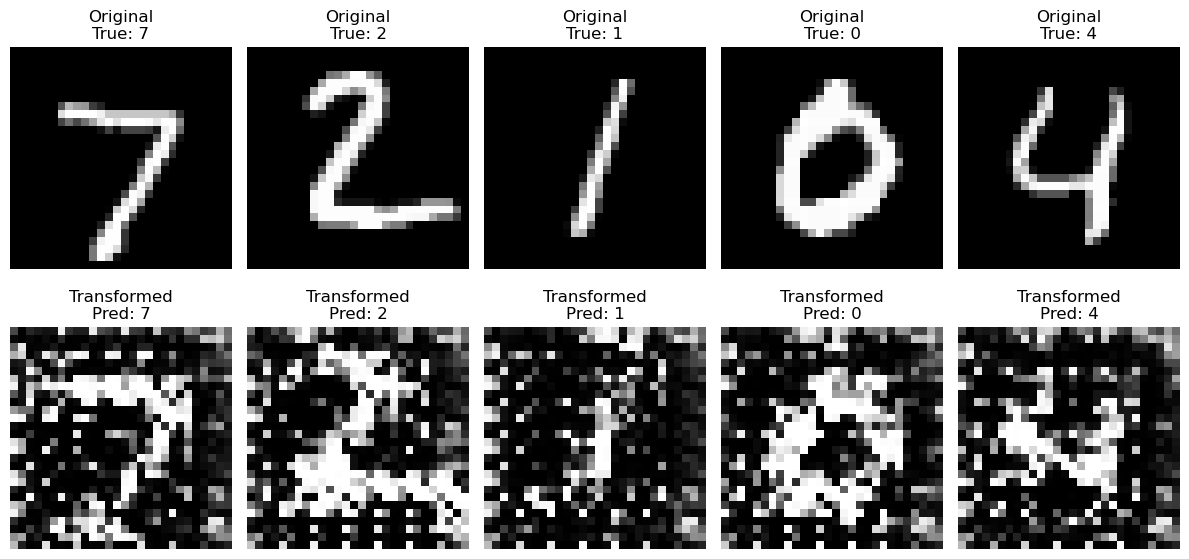

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import KFold
from torch.utils.data import SubsetRandomSampler, ConcatDataset

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Define the logistic regression model
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(28 * 28, 10)  # MNIST has 10 classes

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten image
        return self.linear(x)  # No activation (CrossEntropyLoss applies softmax)

# Define the image transformation network
class ImageTransformNetwork(nn.Module):
    def __init__(self, hidden_dims=64):
        super(ImageTransformNetwork, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, hidden_dims, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dims, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()  # Output in range [-1,1] to match normalization
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Wrapper model that combines transformer and classifier
class CombinedModel(nn.Module):
    def __init__(self, transformer, classifier):
        super(CombinedModel, self).__init__()
        self.transformer = transformer
        self.classifier = classifier
        
        # Freeze the classifier parameters
        for param in self.classifier.parameters():
            param.requires_grad = False
            
    def forward(self, x):
        transformed = self.transformer(x)
        return self.classifier(transformed), transformed

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize and train the logistic regression model
logistic_model = LogisticRegressionModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(logistic_model.parameters(), lr=0.001)

# Create a fixed train/test loader for logistic model training
batch_size = 256
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

print("Training the logistic regression model...")
num_epochs = 8
for epoch in range(num_epochs):
    running_loss = 0
    for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = logistic_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader):.4f}')

# Evaluate logistic regression model
logistic_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = logistic_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Base Logistic Regression Accuracy: {correct / total}')

# Set up k-fold cross-validation
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Convert to list for easy indexing
train_data_list = list(trainset)
train_indices = list(range(len(train_data_list)))

# Define hyperparameters
hidden_dims = 64
classification_weight = 1.0
reconstruction_weight = 0.1
learning_rate = 0.001
num_epochs = 12

# Lists to store the results
fold_accuracies = []
fold_losses = []
epochs_no_improve = 0
patience = 3
print(f"Starting {k_folds}-fold cross-validation for combined model training...")

for fold, (train_idx, val_idx) in enumerate(kf.split(train_indices)):
    print(f"\nFold {fold+1}/{k_folds}")
    
    # Create data loaders for this fold
    train_sampler = SubsetRandomSampler(train_idx)
    val_sampler = SubsetRandomSampler(val_idx)
    
    fold_train_loader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, sampler=train_sampler)
    fold_val_loader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, sampler=val_sampler)
    
    # Initialize a new transformer network for this fold
    transform_net = ImageTransformNetwork(hidden_dims=hidden_dims).to(device)
    combined_model = CombinedModel(transform_net, logistic_model).to(device)
    
    # Define loss functions and optimizer
    classification_criterion = nn.CrossEntropyLoss(reduction='sum')
    reconstruction_criterion = nn.MSELoss(reduction='sum')
    transform_optimizer = optim.Adam(transform_net.parameters(), lr=learning_rate)
    
    # Training loop for this fold
    best_val_acc = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Training phase
        transform_net.train()
        running_loss = 0.0
        running_class_loss = 0.0
        running_recon_loss = 0.0
        
        for images, labels in tqdm(fold_train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)
            
            transform_optimizer.zero_grad()
            
            # Forward pass through the combined model
            outputs, transformed_images = combined_model(images)
            
            # Calculate losses
            classification_loss = classification_criterion(outputs, labels)
            reconstruction_loss = reconstruction_criterion(transformed_images, images)
            
            # Combined loss
            total_loss = classification_weight * classification_loss + reconstruction_weight * reconstruction_loss
            
            # Backward and optimize
            total_loss.backward()
            transform_optimizer.step()
            
            running_loss += total_loss.item()
            running_class_loss += classification_loss.item()
            running_recon_loss += reconstruction_loss.item()
        
        train_loss = running_loss / len(fold_train_loader)
        train_class_loss = running_class_loss / len(fold_train_loader)
        train_recon_loss = running_recon_loss / len(fold_train_loader)
        
        # Validation phase
        transform_net.eval()
        val_loss = 0.0
        val_class_loss = 0.0
        val_recon_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in fold_val_loader:
                images, labels = images.to(device), labels.to(device)
                
                # Forward pass
                outputs, transformed_images = combined_model(images)
                
                # Calculate losses
                classification_loss = classification_criterion(outputs, labels)
                reconstruction_loss = reconstruction_criterion(transformed_images, images)
                total_loss = classification_weight * classification_loss + reconstruction_weight * reconstruction_loss
                
                # Calculate accuracy
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                val_loss += total_loss.item()
                val_class_loss += classification_loss.item()
                val_recon_loss += reconstruction_loss.item()
        
        val_loss = val_loss / len(fold_val_loader)
        val_class_loss = val_class_loss / len(fold_val_loader)
        val_recon_loss = val_recon_loss / len(fold_val_loader)
        val_accuracy = 100 * val_correct / val_total
        
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f} (Class: {train_class_loss:.4f}, Recon: {train_recon_loss:.4f}), '
              f'Val Loss: {val_loss:.4f} (Class: {val_class_loss:.4f}, Recon: {val_recon_loss:.4f}), '
              f'Val Accuracy: {val_accuracy:.2f}%')
        
        # Save the best model for this fold
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_model_state = transform_net.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Load the best model for this fold and evaluate on the test set
    transform_net.load_state_dict(best_model_state)
    combined_model = CombinedModel(transform_net, logistic_model).to(device)
    combined_model.eval()
    
    test_correct = 0
    test_total = 0
    test_loss = 0.0
    
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs, transformed_images = combined_model(images)
            
            # Calculate loss
            classification_loss = classification_criterion(outputs, labels)
            reconstruction_loss = reconstruction_criterion(transformed_images, images)
            total_loss = classification_weight * classification_loss + reconstruction_weight * reconstruction_loss
            
            test_loss += total_loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_accuracy = 100 * test_correct / test_total
    test_loss = test_loss / len(testloader)
    
    print(f'Fold {fold+1} Results - Test Accuracy: {test_accuracy:.2f}%, Test Loss: {test_loss:.4f}')
    
    # Store the results
    fold_accuracies.append(test_accuracy)
    fold_losses.append(test_loss)

# Calculate and print the average results
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
avg_loss = sum(fold_losses) / len(fold_losses)
std_accuracy = np.std(fold_accuracies)

print(f'\nCross-Validation Results:')
print(f'Fold accuracies: {fold_accuracies}')
print(f'Average Test Accuracy: {avg_accuracy:.2f}% ± {std_accuracy:.2f}%')
print(f'Average Test Loss: {avg_loss:.4f}')

# Train the final model using the entire training set
print('\nTraining the final model using the entire training set...')
final_transform_net = ImageTransformNetwork(hidden_dims=hidden_dims).to(device)
final_combined_model = CombinedModel(final_transform_net, logistic_model).to(device)

final_classification_criterion = nn.CrossEntropyLoss(reduction='sum')
final_reconstruction_criterion = nn.MSELoss()
final_transform_optimizer = optim.Adam(final_transform_net.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    final_transform_net.train()
    running_loss = 0.0
    
    for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        final_transform_optimizer.zero_grad()
        
        # Forward pass
        outputs, transformed_images = final_combined_model(images)
        
        # Calculate losses
        classification_loss = final_classification_criterion(outputs, labels)
        reconstruction_loss = final_reconstruction_criterion(transformed_images, images)
        total_loss = classification_weight * classification_loss + reconstruction_weight * reconstruction_loss
        
        # Backward and optimize
        total_loss.backward()
        final_transform_optimizer.step()
        
        running_loss += total_loss.item()
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader):.4f}')

# Final evaluation
final_combined_model.eval()
final_correct = 0
final_total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs, _ = final_combined_model(images)
        _, predicted = torch.max(outputs.data, 1)
        final_total += labels.size(0)
        final_correct += (predicted == labels).sum().item()

final_accuracy = 100 * final_correct / final_total
print(f'Final Enhanced Model Accuracy: {final_accuracy:.2f}%')

# Visualize original vs transformed images with the final model
def visualize_transformation(images, transformed_images, predictions, labels):
    plt.figure(figsize=(12, 6))
    num_images = min(5, images.size(0))
    
    for i in range(num_images):
        # Original image
        plt.subplot(2, num_images, i + 1)
        plt.imshow(images[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original\nTrue: {labels[i].item()}")
        plt.axis('off')
        
        # Transformed image
        plt.subplot(2, num_images, i + num_images + 1)
        plt.imshow(transformed_images[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Transformed\nPred: {predictions[i].item()}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Get some test images
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Get transformed images and predictions
with torch.no_grad():
    outputs, transformed_images = final_combined_model(images)
    _, predictions = torch.max(outputs, 1)

# Denormalize images for visualization (from [-1,1] to [0,1])
images_viz = (images * 0.5) + 0.5
transformed_viz = (transformed_images * 0.5) + 0.5

# Visualize
visualize_transformation(images_viz[:5], transformed_viz[:5], predictions[:5], labels[:5])

Finding examples where the transformation network improved classification...


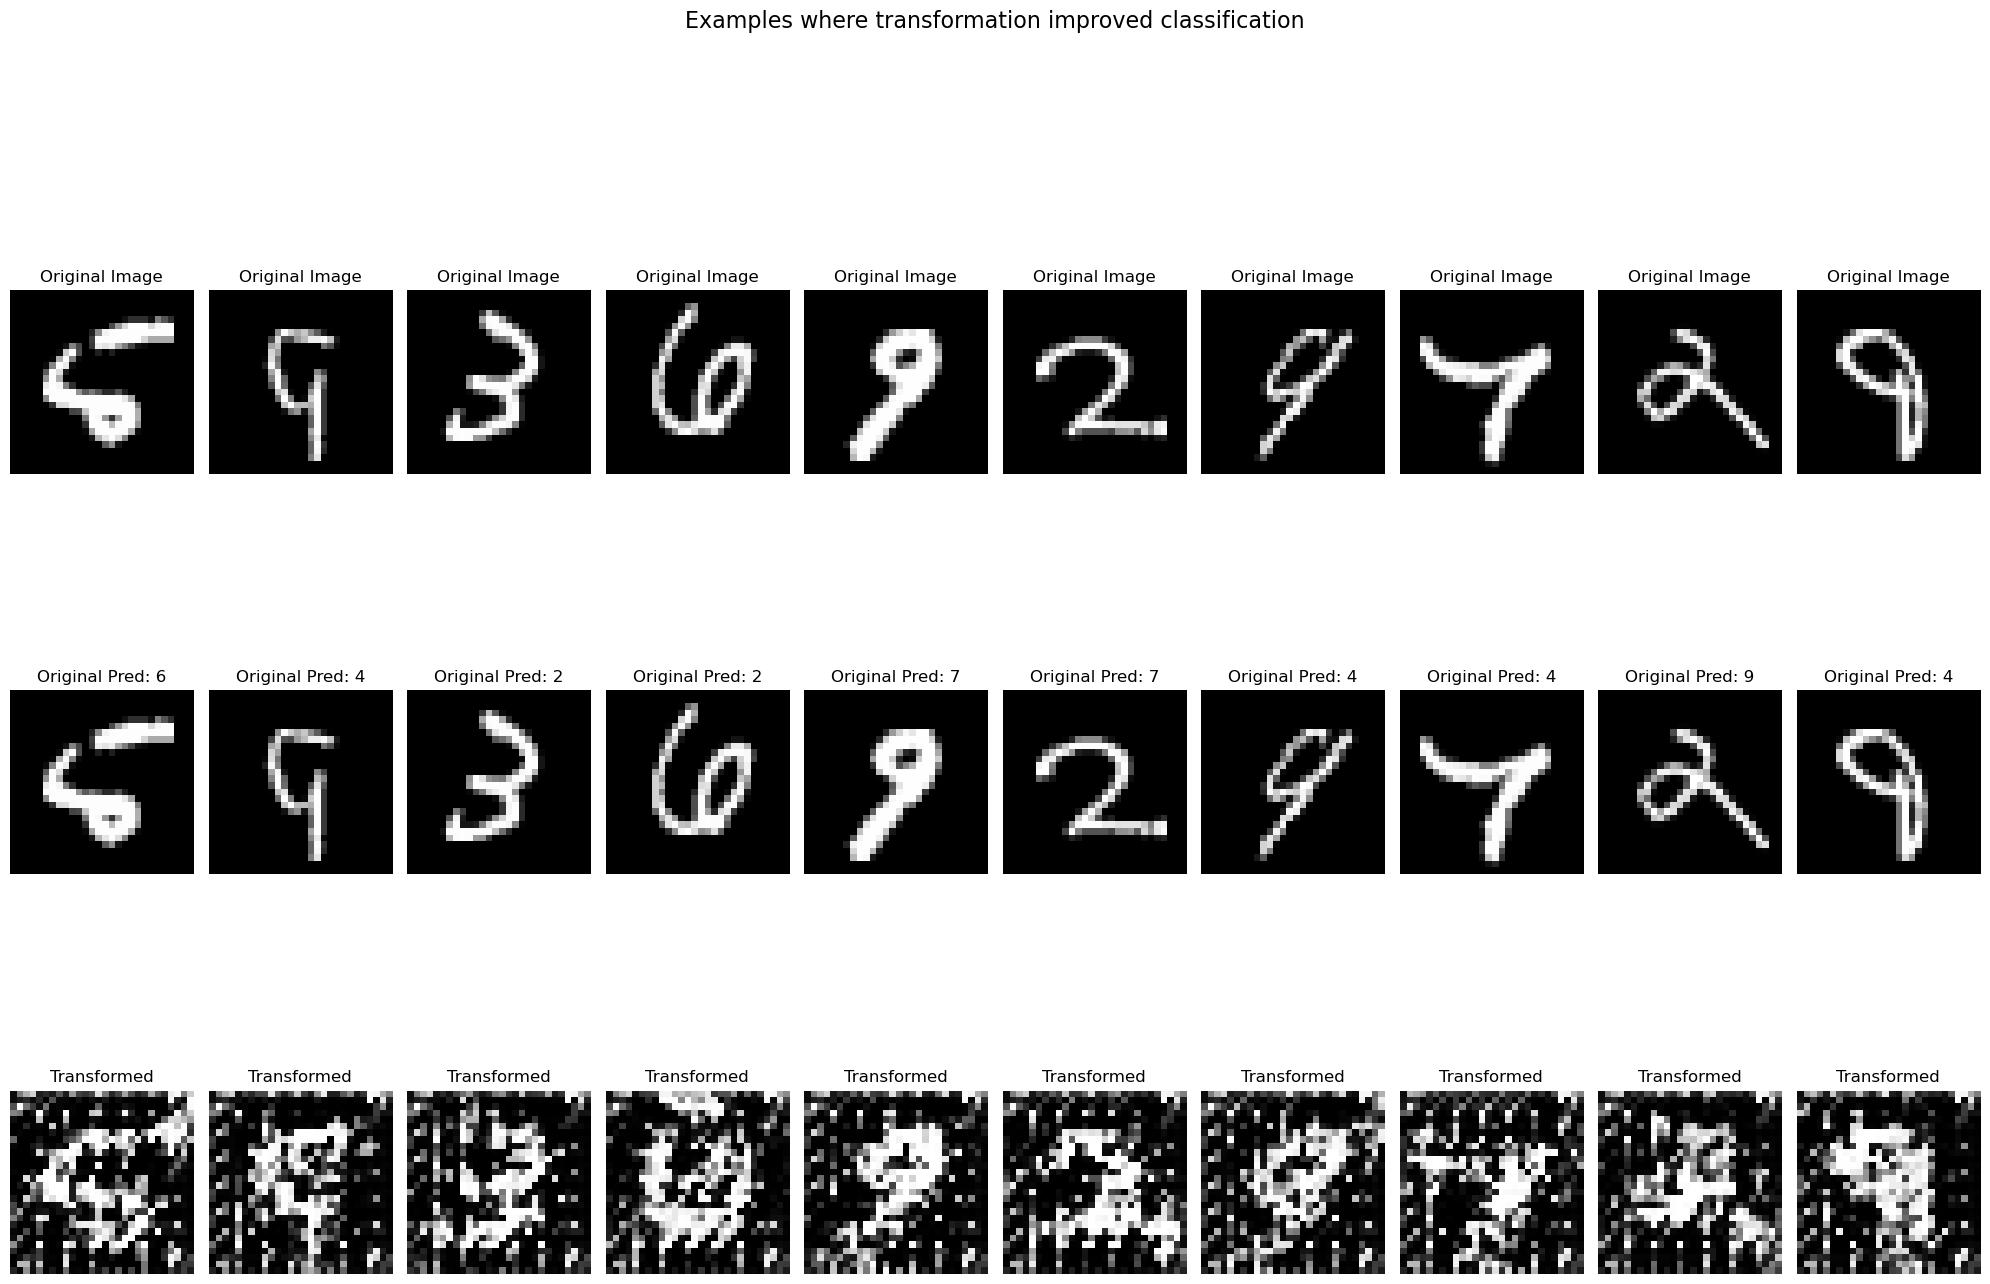

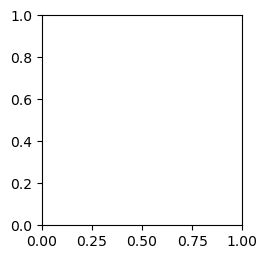

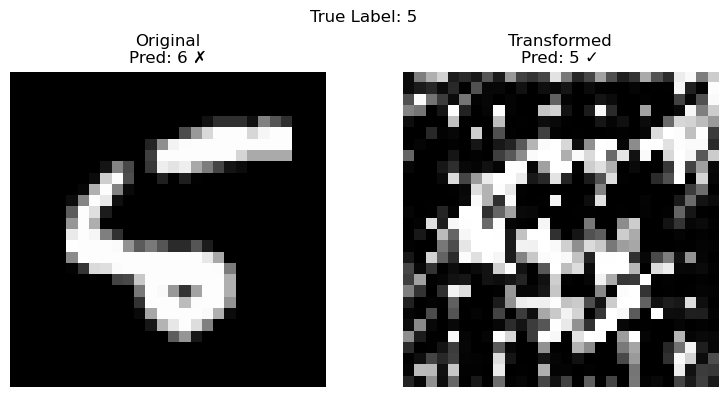

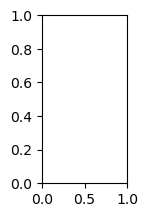

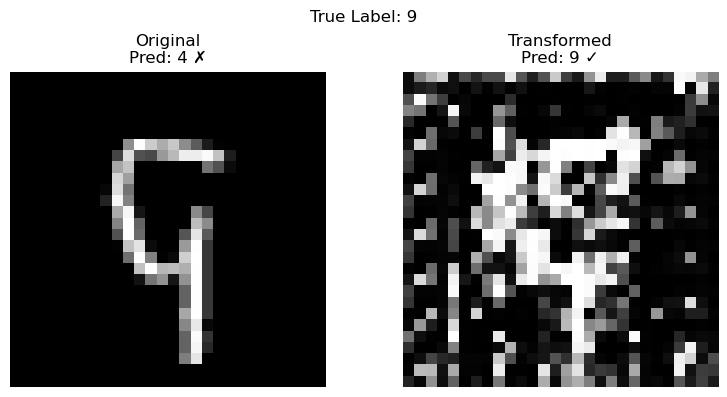

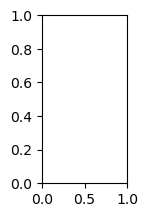

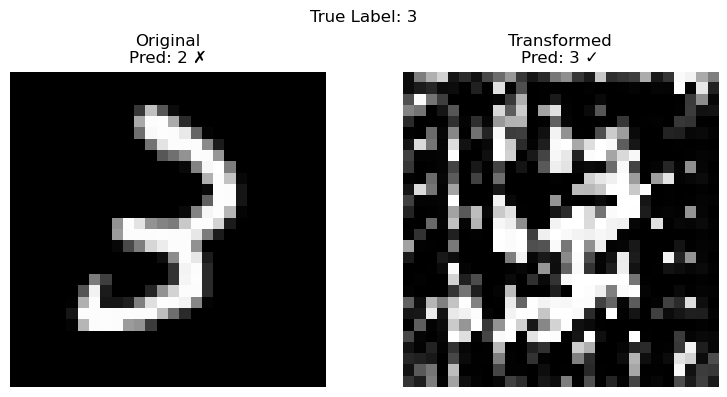

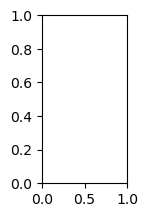

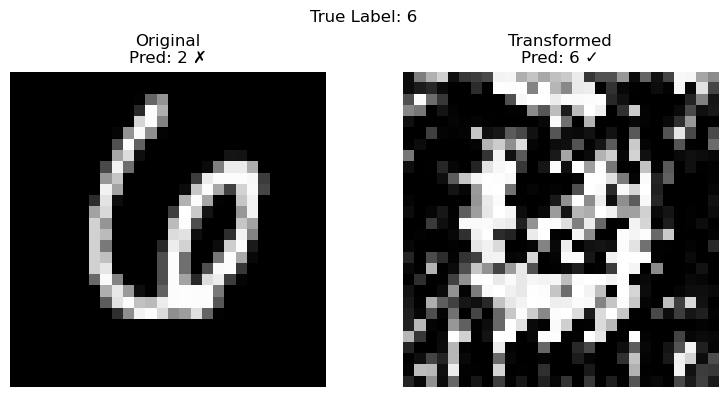

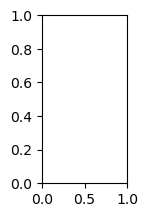

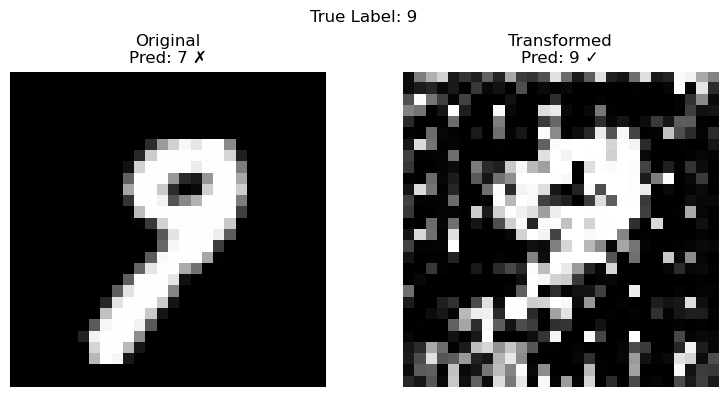

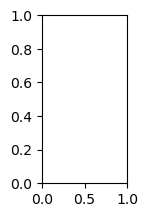

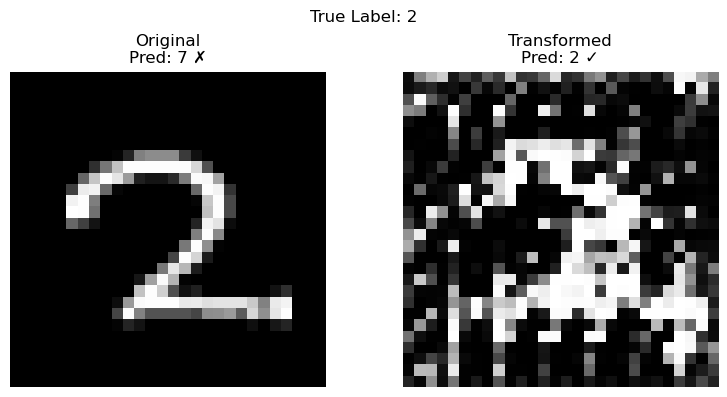

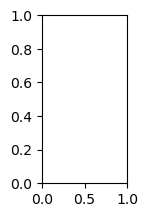

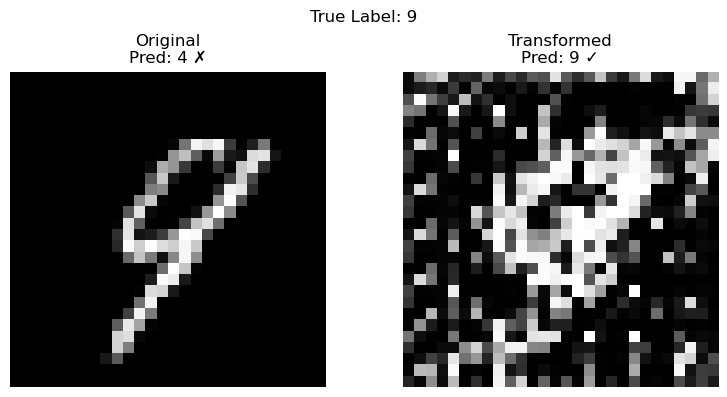

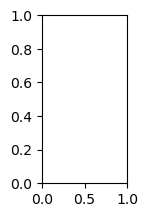

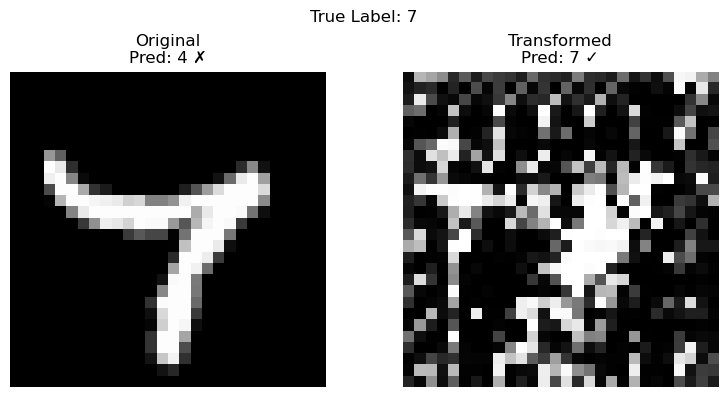

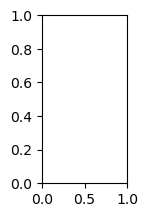

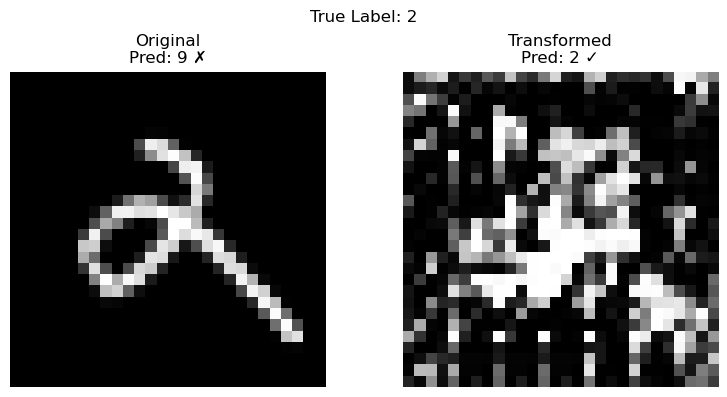

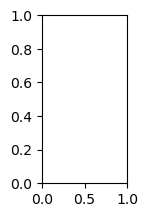

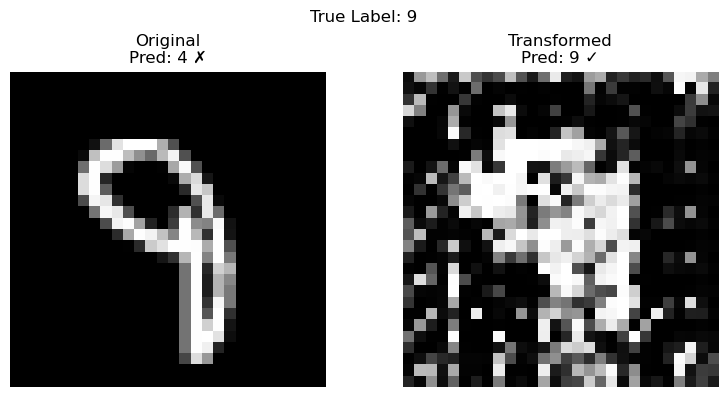

In [13]:
# Code to find and visualize examples where the transformation improved classification
def find_improved_examples(original_model, combined_model, test_loader, num_examples=10):
    original_model.eval()
    combined_model.eval()
    
    improved_images = []
    true_labels = []
    original_preds = []
    improved_preds = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Get predictions from original model
            original_outputs = original_model(images)
            _, original_predictions = torch.max(original_outputs, 1)
            
            # Get predictions from combined model
            combined_outputs, transformed_images = combined_model(images)
            _, combined_predictions = torch.max(combined_outputs, 1)
            
            # Find examples where original model was wrong but combined model is correct
            improved_mask = (original_predictions != labels) & (combined_predictions == labels)
            
            if improved_mask.any():
                improved_images.append((images[improved_mask], transformed_images[improved_mask]))
                true_labels.append(labels[improved_mask])
                original_preds.append(original_predictions[improved_mask])
                improved_preds.append(combined_predictions[improved_mask])
            
            # Check if we have enough examples
            total_found = sum(len(batch) for batch in true_labels)
            if total_found >= num_examples:
                break
    
    # Combine the first num_examples
    selected_images = []
    selected_transformed = []
    selected_labels = []
    selected_original_preds = []
    selected_improved_preds = []
    
    examples_needed = num_examples
    for i in range(len(true_labels)):
        batch_size = len(true_labels[i])
        take = min(examples_needed, batch_size)
        
        selected_images.append(improved_images[i][0][:take])
        selected_transformed.append(improved_images[i][1][:take])
        selected_labels.append(true_labels[i][:take])
        selected_original_preds.append(original_preds[i][:take])
        selected_improved_preds.append(improved_preds[i][:take])
        
        examples_needed -= take
        if examples_needed <= 0:
            break
    
    # Concatenate all selected examples
    if selected_images:
        selected_images = torch.cat(selected_images)
        selected_transformed = torch.cat(selected_transformed)
        selected_labels = torch.cat(selected_labels)
        selected_original_preds = torch.cat(selected_original_preds)
        selected_improved_preds = torch.cat(selected_improved_preds)
        
        return selected_images, selected_transformed, selected_labels, selected_original_preds, selected_improved_preds
    else:
        return None

# Find examples where transformation improved classification
print("Finding examples where the transformation network improved classification...")
improved_data = find_improved_examples(logistic_model, combined_model, testloader, num_examples=10)

if improved_data:
    images, transformed_images, true_labels, original_preds, improved_preds = improved_data
    
    # Denormalize images for visualization (from [-1,1] to [0,1])
    images_viz = (images * 0.5) + 0.5
    transformed_viz = (transformed_images * 0.5) + 0.5
    
    # Visualize the improved examples
    plt.figure(figsize=(20, 15))
    
    for i in range(min(10, images.size(0))):
        # Original image with incorrect prediction
        plt.subplot(3, 10, i + 1)
        plt.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original Image")
        plt.axis('off')
        
        # Original prediction (incorrect)
        plt.subplot(3, 10, i + 11)
        plt.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original Pred: {original_preds[i].item()}")
        plt.xlabel(f"True Label: {true_labels[i].item()}")
        plt.axis('off')
        
        # Transformed image with correct prediction
        plt.subplot(3, 10, i + 21)
        plt.imshow(transformed_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Transformed")
        plt.xlabel(f"Pred: {improved_preds[i].item()} ✓")
        plt.axis('off')
    
    plt.suptitle("Examples where transformation improved classification", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    # Additional detailed 2x5 grid visualization
    plt.figure(figsize=(15, 6))
    for i in range(min(10, images.size(0))):
        plt.subplot(2, 5, i + 1)
        
        # Create a side-by-side comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
        
        # Original image
        ax1.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        ax1.set_title(f"Original\nPred: {original_preds[i].item()} ✗")
        ax1.axis('off')
        
        # Transformed image
        ax2.imshow(transformed_viz[i].cpu().squeeze().numpy(), cmap='gray')
        ax2.set_title(f"Transformed\nPred: {improved_preds[i].item()} ✓")
        ax2.axis('off')
        
        plt.suptitle(f"True Label: {true_labels[i].item()}")
        plt.tight_layout()
        plt.show()
else:
    print("Could not find enough examples where transformation improved classification.")
    print("This could mean either the original model is already very accurate or the transformation did not help significantly.")
    print("Try running the training for more epochs or adjusting the transformation network architecture.")